# 02 - Features & Selection

Builds the pooled walk-forward feature space and compresses it, independently per
target family.

Two design points worth keeping in view:

* **The build is shared.** Rolling priors depend on `(L, alpha)` and the source
  stat -- not on which family is being predicted. All four targets read the same
  matrix, which is what makes a four-family search affordable.
* **Cross-family features are allowed.** A shots prior is a legitimate candidate
  for the goals model. Whether it survives is a selection question, not a
  modelling one.

In [1]:
# The package is installed editable (`pip install -e .`), so this works from any
# working directory -- no `os.getcwd()` gymnastics.
import fpp
import numpy as np
import pandas as pd

# Hoisted here rather than sitting in the config cell below: the fold-noise
# diagnostic runs *before* config now, and needs CORE_FEATURES and PROBE.
from fpp.spec import ALL_FEATURE_NAMES, CORE_FEATURES, feature_groups
from fpp.config import PROBE

pd.set_option("display.max_columns", None)
print("fpp", fpp.__version__, "| targets:", fpp.TARGETS)

fpp 0.1.0 | targets: ('goals', 'shots', 'sot', 'corners')


## 1. Load and build

`BufferWindows` does the expensive layout work once -- sorting, grouping, padding --
so each `(L, alpha)` afterwards costs only a weighted slice-sum.

In [2]:
df = fpp.clean.load_clean_table()
bw = fpp.BufferWindows(df, L_max=50)

L0, ALPHA0 = 20, 0.05
ft = fpp.build_feature_table(df, bw, L0, ALPHA0)
folds = fpp.cv.season_folds(ft)

print(f"X {ft.X.shape}  |  {len(ft)} rows kept of {len(df)}")
print("validation folds:", [f.val_season for f in folds])
print("test seasons held out:", sorted(set(ft.meta.loc[fpp.cv.test_mask(ft), 'season'])))

X (39616, 59)  |  39616 rows kept of 43268
validation folds: ['2020/2021', '2021/2022', '2022/2023', '2023/2024', '2024/2025']
test seasons held out: ['2526', '2627']


### Leakage guard

The single most important property: a prior may only ever see *strictly earlier*
matches. A team's first row must therefore have no prior at all.

In [3]:
p = bw.priors(L0, ALPHA0)
first_rows = df.groupby("team", observed=True).head(1).index.to_numpy()
assert all(np.isnan(p[b][first_rows]).all() for b in p), "a prior leaked into a team's first match"
print("leakage guard passed - no prior sees its own match")
print("(`pytest tests/test_priors.py` additionally checks the vectorised engine")
print(" against a row-at-a-time reference implementation)")

leakage guard passed - no prior sees its own match
(`pytest tests/test_priors.py` additionally checks the vectorised engine
 against a row-at-a-time reference implementation)


### Fold noise — what to set `SELECTION_TOL` against

The tolerance is an absolute log-loss slack, so it only means something next to the
noise it has to clear. Measure that first, then set the dial — rather than setting
the dial and discovering the noise afterwards.

Cheap by design: `CORE_FEATURES` and `PROBE`, four CV fits reusing the `ft` and
`folds` built above.

In [4]:
from fpp.models import base_params
from fpp.spec import ALL_FEATURE_NAMES

# Fold noise per target, measured TWO ways, because they are not the same number
# and the difference is itself diagnostic.
#
#   CORE_FEATURES  -- cheap, 10 features. What this cell used to print alone.
#   full candidate -- all 59. **This is the one the outer check gates on**:
#                     `search.stages` computes `full_model_ll, full_se` on the
#                     full set and builds its budgets as
#                     `full_model_ll + MULT * full_se`.
#
# Printing only the core number was misleading. For goals the two agree (0.00274
# vs 0.00279) so the distinction never surfaced; for shots they differ 4.3x
# (0.00614 vs 0.00143), so a tolerance "set against the fold SE" was really being
# set against a number four times too big.
#
# The gap is worth reading, not just correcting. A target whose full-set SE is far
# BELOW its core SE is one the extra features genuinely stabilise -- shots gains
# 0.028 of log loss and drops to a quarter of the scatter, which is the same fact
# that makes it refuse to compress later.
print("fold noise per target -- set SELECTION_TOL against the FULL-SET column\n")
print(f"  {'target':<9} {'core ll':>10} {'core SE':>10} | {'full ll':>10} {'full SE':>10}   {'ratio':>7}")
for t in fpp.TARGETS:
    core = fpp.cv.evaluate(ft, t, base_params(t, PROBE), folds,
                           features=list(CORE_FEATURES), fit_cfg=PROBE)
    full = fpp.cv.evaluate(ft, t, base_params(t, PROBE), folds,
                           features=list(ALL_FEATURE_NAMES), fit_cfg=PROBE)
    ratio = core.se / full.se if full.se else float("nan")
    flag = "   <-- core SE is a poor proxy here" if ratio > 2 or ratio < 0.5 else ""
    print(f"  {t:<9} {core.mean:>10.6f} {core.se:>10.6f} | "
          f"{full.mean:>10.6f} {full.se:>10.6f}   {ratio:>6.1f}x{flag}")

print("\nThe full-set SE is what `run_feature_selection` reports and what its outer")
print("budgets are built from. The core column is kept only for the comparison.")


fold noise per target -- set SELECTION_TOL against the FULL-SET column

  target       core ll    core SE |    full ll    full SE     ratio
  goals       1.458284   0.002754 |   1.456444   0.002806      1.0x
  shots       2.877319   0.006123 |   2.849545   0.001467      4.2x   <-- core SE is a poor proxy here
  sot         2.167084   0.004232 |   2.153878   0.006592      0.6x
  corners     2.332992   0.005976 |   2.323658   0.006688      0.9x

The full-set SE is what `run_feature_selection` reports and what its outer
budgets are built from. The core column is kept only for the comparison.


In [5]:
# ---------------------------------------------------------------------------
# INNER TOLERANCE -- the dial to turn when a target over- or under-prunes.
#
# Absolute log-loss slack governing each GROUP's own culling inside stages 1-3.
# A candidate subset is eligible if it scores within this much of the reference;
# among the eligible, the smallest set wins.
#
#   TIGHTER (smaller)  ->  keeps MORE features (harder to justify dropping one)
#   LOOSER  (larger)   ->  prunes harder
#
# Now a STARTING value, not a fixed one: a stage whose combined output misses the
# outer budget shrinks this by RETRY_SHRINK_PCT and culls again from full
# membership, until it passes or bottoms out at zero.
#
# Set these against the fold SE printed by the cell ABOVE -- that is why the
# diagnostic runs first. Measured so far:
#
#   goals:   0.00278   (diagnostic SE 0.002162)
#   shots:   0.05578   (diagnostic SE 0.060320)
#   sot:     0.01410   (diagnostic SE 0.016455)
#   corners: ?         (diagnostic SE 0.008086)
#
# The four are independent -- change one without touching the others.
#
# Changing one of these is safe without wiping the cache: stages 2 and 3
# fingerprint the backdrop they were scored against, so a different tolerance
# produces different cache keys rather than silently reusing rows measured
# against a survivor set that no longer exists.
# ---------------------------------------------------------------------------
SELECTION_TOL = {
    "goals":   0.002806,
    "shots":   0.001467,
    "sot":     0.006592,
    "corners": 0.006688,
}

# How much to tighten the inner tolerance on each retry. 0.20 -> each attempt is
# 80% of the last. Package default lives in fpp/config.py; this is the dial.
RETRY_SHRINK_PCT = 0.05

# ---------------------------------------------------------------------------
# OUTER CHECK -- fixed, never shrinks, measured against the FULL MODEL.
#
# After each stage culls its groups and recombines them, the combined set must
# score within a fixed multiple of the fold SE of the full model -- all 57
# candidate features:
#
#     combined_ll <= full_model_ll + MULT * fold_se
#
# NOT the naive per-league baseline computed in section 2 below. Those are two
# different numbers -- for goals, a full model near 1.4568 against a naive
# baseline near 1.5212 -- and gating on the naive one is a far looser bar that
# would pass real compression damage. The question here is "is the compressed
# set still as good as using everything", so the full model is what it measures.
#
# The naive baseline is untouched and still computed below; it just is not what
# this check uses. "Baseline" keeps its established meaning in this codebase
# (`league_mean_baseline`, and every comparison in evaluate.py).
#
# Full model rather than ANCHOR because the anchor is itself stage 1's output:
# gating later stages on it lets an over-pruned stage 1 move the bar for
# everything downstream instead of being caught. ANCHOR is still printed, and is
# informational past stage 1.
#
# `run_feature_selection` already computes the full model internally, so no
# argument is passed for this -- the check reuses that value.
#
# Stages 4 and 5 need no retry -- each always has a guaranteed-passing candidate
# among its own (keep every group / keep everything stage 4 kept), so neither can
# come back worse than what already passed one stage earlier.
# ---------------------------------------------------------------------------
# PER TARGET, and now actually plumbed through -- these used to be scalars that
# `run_feature_selection` never read, so setting them here changed nothing while
# looking identical to the dials beside them that do work. The call below passes
# them explicitly.
#
# Raise one only with a reason. shots is the case in point: its cheapest stage-1
# cull costs 2.18x its fold SE, so at 1.0 nothing can ever pass, stage 1 falls
# back to all 59 features, and stage 2 then inherits the maximal 12-member merged
# groups (16,528 subsets) the design explicitly avoids. 2.2 is set to clear that
# 2.18, not picked for roundness.
ANCHOR_FULL_MULT = {     # stage 1, whose combined output becomes the ANCHOR
    "goals": 1.0,
    "shots": 2.2,
    "sot": 1.0,
    "corners": 1.0,
}
STAGE_FULL_MULT = {      # stages 2-5
    "goals": 2.0,
    "shots": 3.0,
    "sot": 2.0,
    "corners": 1.2,
}

# Final backstop after stage 5. Should fire far less often now: stages 1-3 fall
# back to full membership rather than ship a set that cannot clear the budget, so
# reaching it means even keeping everything came in more than the budget worse
# than the full model -- worth investigating rather than routine.
# Set False to accept such a result anyway (it still prints a warning).
FAIL_ON_REGRESSION = True

# Print every subset's score in each group's search, not just the winner, so a
# dropped group is visibly a close call or a landslide. Verbose -- a stage-1 pass
# is 592 lines per target, and each retry repeats it -- but it is the difference
# between checking a result and taking it on trust. Every trial also lands in the
# checkpoint CSV regardless.
PRINT_TRIALS = True

fpp.spec.validate()
groups = feature_groups()
print(f"{len(ALL_FEATURE_NAMES)} candidate features in {len(groups)} stage-1 groups")
print("(points is deliberately NOT a candidate -- see NON_CANDIDATE_STATS in fpp/spec.py)")
print(f"largest group: {max(len(v) for v in groups.values())} members "
      f"-> {2 ** max(len(v) for v in groups.values())} subsets")
print(f"pass-1 cost: {sum(2 ** len(v) for v in groups.values())} evaluations per target "
      f"(cached across retries -- only the combined score is re-fitted)")

59 candidate features in 10 stage-1 groups
(points is deliberately NOT a candidate -- see NON_CANDIDATE_STATS in fpp/spec.py)
largest group: 7 members -> 128 subsets
pass-1 cost: 656 evaluations per target (cached across retries -- only the combined score is re-fitted)


## 2. Baseline

Per-league mean rate. Naive by design -- and for goals a genuinely hard bar, because
goals are close to pure Poisson noise, leaving little predictable signal above the
league average.

Measured with the **per-team** metric, the same one `cv.evaluate` optimises, so the
baseline and the anchor are directly comparable.

In [6]:
from fpp.models import base_params

# Scored with `score_team_logloss`, matching `cv.evaluate` -- NOT the match-total
# metric. The baseline and the anchor have to be measured the same way or every
# comparison built on top of them (the `edge` printed when saving, and
# `baseline_logloss` stored in the artifact) compares two different quantities.
baseline = {}
for t in fpp.TARGETS:
    tr = fpp.cv.dev_mask(ft)
    paired = fpp.models.league_mean_baseline(ft.mask(tr), ft.mask(tr), t)
    ll = fpp.models.score_team_logloss(paired, t, None)
    baseline[t] = float(np.mean(ll))
    print(f"  {t:8} baseline per-team logloss {baseline[t]:.4f}")

print()
print(f"scoring mode: {fpp.config.SCORING_MODE!r}  (fingerprint {fpp.spec.scoring_hash()})")
print("note: fitted and scored on the dev seasons, so this is an in-sample")
print("      reference point, not a held-out one -- 04_Evaluation is the held-out test")

  goals    baseline per-team logloss 1.5233
  shots    baseline per-team logloss 2.9812
  sot      baseline per-team logloss 2.2586
  corners  baseline per-team logloss 2.3969

scoring mode: 'team'  (fingerprint 5342c5fa)
note: fitted and scored on the dev seasons, so this is an in-sample
      reference point, not a held-out one -- 04_Evaluation is the held-out test


## 3. Feature selection

Grouped compression driven by walk-forward CV, with SHAP as a diagnostic rather
than a decision rule.

**Two tolerance tiers.** The *inner* tolerance (`SELECTION_TOL`) governs each
group's own culling in stages 1–3: keep the smallest subset within an absolute
slack of the reference, not the outright lowest, because chasing the best number
fits CV noise. The *outer* check is separate and fixed — each stage's **combined**
output must land within a set multiple of the fold SE of the **full model**.

That split exists because the inner tolerance is applied *per group*. Ten groups
each conceding a little compounds into a combined set far worse than any single
group's band suggests, and nothing was checking the combined result until it was
too late.

⚠️ **The outer check gates on the full model, not the naive baseline.** Both exist
and they are far apart — for goals, ~1.4568 against ~1.5212. Section 2's baseline
is untouched and still stored in the artifact, but it is a much looser bar and is
not what this gate uses. The question here is "is the compressed set still as good
as using everything". Full model rather than `ANCHOR` for a different reason: the
anchor is itself stage 1's output, so gating on it would let an over-pruned
stage 1 move the bar instead of being caught.

A stage that misses its budget shrinks its inner tolerance and culls again **from
full membership** — never from the previous attempt's survivors. One that cannot
pass even at `tol=0` stops compressing and keeps everything, rather than failing
the run. Stages 4 and 5 never retry: each always scores a guaranteed-passing
candidate among its own, so neither can return worse than what already passed.

Retries are cheaper than they look: the per-group scores are checkpointed and the
backdrop is fixed for the whole loop, so a retry re-uses them and only re-fits the
*combined* score — and identical combined sets are memoised, so shrinking to the
floor costs a couple of extra fits, not sixty.

Scored per team: each side is judged against its own actual, the same objective
`cv.evaluate` optimises. Every stage inherits it from there.

Checkpointed and resumable. Filenames fingerprint the group structure, the window
and the scoring definition; stage 2/3 points additionally fingerprint the backdrop
they were scored against, so changing a tolerance re-evaluates rather than
silently reusing rows measured against a survivor set that no longer exists.

In [7]:
RUN_SELECTION = True   # ~10-20 min for all four families, more if stages retry

results = {}
if RUN_SELECTION:
    for t in fpp.TARGETS:
        print(f"\n=== {t} ===")
        ckpt = fpp.paths.search_checkpoint(t, "feature_subsets")
        # No reference passed for the outer check: it gates on the full model,
        # which run_feature_selection already computes internally.
        results[t] = fpp.search.run_feature_selection(
            ft, t, ckpt, fit_cfg=PROBE, tol=SELECTION_TOL[t],
            shrink=RETRY_SHRINK_PCT,
            anchor_mult=ANCHOR_FULL_MULT[t], stage_mult=STAGE_FULL_MULT[t],
            fail_on_regression=FAIL_ON_REGRESSION, print_trials=PRINT_TRIALS,
        )
else:
    print("skipped - set RUN_SELECTION = True to run.")
    print("Falling back to CORE_FEATURES so the rest of the notebook still executes.")
    for t in fpp.TARGETS:
        results[t] = {"selected": list(CORE_FEATURES), "provisional": list(CORE_FEATURES),
                      "provisional_stage1": list(CORE_FEATURES),
                      "provisional_stage2": list(CORE_FEATURES),
                      "provisional_stage3": list(CORE_FEATURES),
                      "group_winners_stage1": {}, "group_winners_stage2": {},
                      "group_winners_stage3": {}, "merged_groups": {},
                      "groups_kept": [], "shap_rank": [],
                      "tol": SELECTION_TOL[t], "retries": {}, "band_counts": {},
                      "stage_budget": float("nan"),
                      "anchor_logloss": float("nan"), "full_logloss": float("nan")}

# Compression summary. A group that earns no place is *dropped* -- it must not
# contribute a placeholder to the feature list.
print()
print("stage 1    does each group carry signal ON ITS OWN?  (isolated, no backdrop)")
print("stage 2-3  which of those survivors matter once end-product and process MERGE")
print("stage 4    which whole groups earn their place")
print("final      exhaustive n=1..k over the INDIVIDUAL features surviving stage 4")
print()
print("Two tolerance tiers:")
print("  inner  = SELECTION_TOL, per-group culling in stages 1-3; SHRINKS on retry")
print("  outer  = FULL MODEL + MULT x fold SE, on each stage's COMBINED output;")
print("           fixed, never shrinks. A stage that cannot pass it even at tol=0")
print("           keeps full membership rather than failing the run.")
print()
print("Three scores, none interchangeable:")
print("  full model = every candidate feature   -- what the outer check gates on")
print("  anchor     = stage-1 survivors combined -- informational past stage 1")
print("  baseline   = naive per-league mean      -- a DIFFERENT, looser number;")
print("               used in section 2 and in evaluate.py, NOT by this gate")
print()
print(f"{'target':9} {'tol0':>8} {'full':>5} {'s1':>4} {'s2':>4} {'s3':>4} {'s4':>4} "
      f"{'final':>5}   {'full ll':>10} {'final ll':>10}  retries")
for t in fpp.TARGETS:
    r = results[t]
    retried = ", ".join(
        f"{s}:{d['attempts']}x@{d['tol']:.5f}" + ("!FB" if d["fell_back"] else "")
        for s, d in r.get("retries", {}).items() if d["attempts"] > 1 or d["fell_back"]
    ) or "-"
    print(f"{t:9} {r.get('tol', float('nan')):8.5f} {len(ALL_FEATURE_NAMES):5} "
          f"{len(r.get('provisional_stage1', [])):4} {len(r.get('provisional_stage2', [])):4} "
          f"{len(r.get('provisional_stage3', [])):4} {len(r.get('provisional', [])):4} "
          f"{len(r['selected']):5}   {r.get('full_logloss', float('nan')):10.6f} "
          f"{r.get('logloss', float('nan')):10.6f}  {retried}")
    unknown = set(r["selected"]) - set(ALL_FEATURE_NAMES)
    assert not unknown, f"{t}: selection leaked non-features {sorted(unknown)}"
    assert len(set(r["selected"])) == len(r["selected"]), f"{t}: duplicate features selected"

print("\n(!FB = that stage hit the tolerance floor and kept full membership)")

for t in fpp.TARGETS:
    kept = results[t].get("groups_kept", [])
    if kept:
        print(f"\n  {t} kept {len(kept)} group(s): {kept}")
        for f in results[t]["selected"]:
            print(f"      {f}")


=== goals ===
  [goals] full model (59 features): logloss 1.456444   [the outer check's reference]
  [goals] inner tolerance 0.002806 (absolute log loss; fold SE 0.00281; shrinks 5% per retry)
  [goals] outer check vs FULL MODEL: stage 1 budget 1.459249 (1x SE), stages 2-5 budget 1.462055 (2x SE)
  [goals] stage1 team_attack: 64 subsets scored (delta vs group best 1.481824)
        n= 4  ll=1.481824  delta=+0.00000  ['team_avg_goals_for', 'team_avg_goals_for_v', 'team_avg_xg_for_v', 'team_avg_npxg_for']
        n= 6  ll=1.481839  delta=+0.00002  ['team_avg_goals_for', 'team_avg_goals_for_v', 'team_avg_xg_for', 'team_avg_xg_for_v', 'team_avg_npxg_for', 'team_avg_npxg_for_v']
        n= 5  ll=1.481858  delta=+0.00003  ['team_avg_goals_for', 'team_avg_goals_for_v', 'team_avg_xg_for', 'team_avg_xg_for_v', 'team_avg_npxg_for_v']
        n= 3  ll=1.481867  delta=+0.00004  ['team_avg_goals_for', 'team_avg_xg_for_v', 'team_avg_npxg_for']
        n= 5  ll=1.481878  delta=+0.00005  ['team_avg_g

## 4. SHAP diagnostic

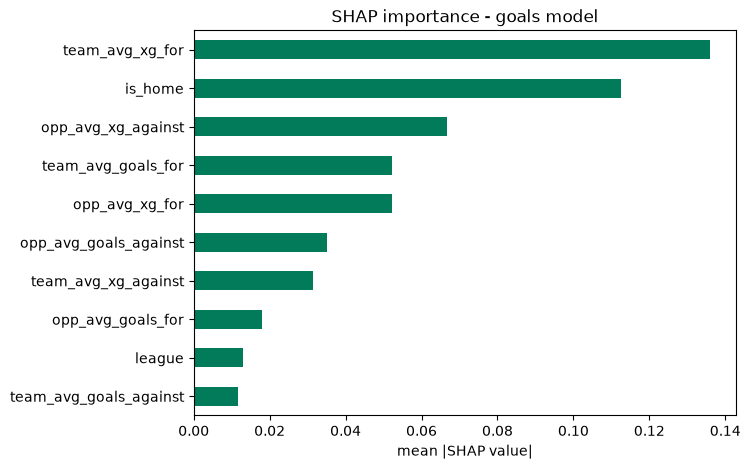

In [8]:
shap = fpp.search.shap_importance(ft, "goals", list(CORE_FEATURES), PROBE)
ax = shap.sort_values().plot.barh(figsize=(7, 5), color="#027B5B",
                                  title="SHAP importance - goals model")
ax.set_xlabel("mean |SHAP value|");

## 5. Save the starting point for tuning

Writes `window` and `features` artifacts per target family. Tuning picks these up.

In [9]:
VERSION = fpp.artifacts.working_version()

for t in fpp.TARGETS:
    r = fpp.cv.evaluate(ft, t, base_params(t, PROBE), folds,
                        features=results[t]["selected"], fit_cfg=PROBE)
    fpp.artifacts.save_artifact(t, "window", {"L": L0, "alpha": ALPHA0,
                                              "L_venue": int(np.ceil(0.5 * L0))}, VERSION)
    fpp.artifacts.save_artifact(t, "features", {
        "selected": results[t]["selected"],
        "provisional": results[t].get("provisional", []),
        "provisional_stage1": results[t].get("provisional_stage1", []),
        "provisional_stage2": results[t].get("provisional_stage2", []),
        "provisional_stage3": results[t].get("provisional_stage3", []),
        "group_winners_stage1": results[t].get("group_winners_stage1", {}),
        "group_winners_stage2": results[t].get("group_winners_stage2", {}),
        "group_winners_stage3": results[t].get("group_winners_stage3", {}),
        "merged_groups": results[t].get("merged_groups", {}),
        "groups_kept": results[t].get("groups_kept", []),
        # the starting dial, and what each stage actually settled at after
        # retrying -- a result is only attributable with both
        "tol": results[t].get("tol"),
        "retries": results[t].get("retries", {}),
        "band_counts": results[t].get("band_counts", {}),
        # the outer check's reference and the budget it implied
        "stage_budget": results[t].get("stage_budget"),
        # informational references -- neither gates anything
        "anchor_logloss": results[t].get("anchor_logloss"),
        "full_logloss": results[t].get("full_logloss"),
        "shap_rank": results[t].get("shap_rank", []),
        "logloss": r.mean, "baseline_logloss": baseline[t],
    }, VERSION)
    fb = [s for s, d in results[t].get("retries", {}).items() if d.get("fell_back")]
    print(f"  {t:8} {len(results[t]['selected']):2d} features  "
          f"ll={r.mean:.4f}  baseline={baseline[t]:.4f}  edge={baseline[t] - r.mean:+.4f}"
          + (f"   [{', '.join(fb)} kept full membership]" if fb else ""))

print(f"\nartifacts -> {fpp.paths.ARTIFACTS}/<target>/{VERSION}/")

  goals     5 features  ll=1.4620  baseline=1.5233  edge=+0.0613
  shots    12 features  ll=2.8538  baseline=2.9812  edge=+0.1274
  sot       4 features  ll=2.1639  baseline=2.2586  edge=+0.0947
  corners   4 features  ll=2.3308  baseline=2.3969  edge=+0.0661

artifacts -> /Users/patrickknott/Desktop/Football_Prediction_Project V2/artifacts/<target>/v2026-08-25/
